In [ ]:
!pip install open_clip_torch==2.20.0
!pip install 'git+https://github.com/facebookresearch/detectron2.git'

  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-xykww1jn
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-xykww1jn
  Resolved https://github.com/facebookresearch/detectron2.git to commit b599f139756bd3646a26a909caf86a1a159e53a7
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 31.0 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp312-cp312-linux_x86_64.whl size=7111507 sha2

In [ ]:
!sed -i 's/AT_DISPATCH_FLOATING_TYPES(value\.type()/AT_DISPATCH_FLOATING_TYPES(value.scalar_type()/g' \
  /content/FC-CLIP/fc-clip-main/fcclip/modeling/pixel_decoder/ops/src/cuda/ms_deform_attn_cuda.cu

!sed -i 's/value\.type()\.is_cuda()/value.is_cuda()/g' \
  /content/FC-CLIP/fc-clip-main/fcclip/modeling/pixel_decoder/ops/src/ms_deform_attn.h

%cd /content/FC-CLIP/fc-clip-main/fcclip/modeling/pixel_decoder/ops
!sh make.sh

sed: can't read /content/FC-CLIP/fc-clip-main/fcclip/modeling/pixel_decoder/ops/src/cuda/ms_deform_attn_cuda.cu: No such file or directory
sed: can't read /content/FC-CLIP/fc-clip-main/fcclip/modeling/pixel_decoder/ops/src/ms_deform_attn.h: No such file or directory
[Errno 2] No such file or directory: '/content/FC-CLIP/fc-clip-main/fcclip/modeling/pixel_decoder/ops'
/content
sh: 0: cannot open make.sh: No such file


In [ ]:
!pip install gdown
!gdown 1tcB-8FNON-LwckXQbUyKcBA2G7TU65Zh -O /content/fc_clip_r50.pth

Downloading...
From (original): https://drive.google.com/uc?id=1tcB-8FNON-LwckXQbUyKcBA2G7TU65Zh
From (redirected): https://drive.google.com/uc?id=1tcB-8FNON-LwckXQbUyKcBA2G7TU65Zh&confirm=t&uuid=b886bb56-1f60-48ca-a46f-123c9f9f84fb
To: /content/fc_clip_r50.pth
100% 84.3M/84.3M [00:02<00:00, 36.8MB/s]


In [ ]:
%cd /content/drive/MyDrive/FC-CLIP/fc-clip-main

/content/drive/MyDrive/FC-CLIP/fc-clip-main


In [ ]:
!python demo/demo.py \
  --config-file configs/coco/panoptic-segmentation/fcclip/fcclip_convnext_large_eval_ade20k_r50.yaml \
  --input /content/drive/MyDrive/FC-CLIP/기찻길.jpg /content/drive/MyDrive/FC-CLIP/다람쥐.jpg /content/drive/MyDrive/FC-CLIP/볼가사리.jpg \
  --output /content/output/ \
  --opts MODEL.WEIGHTS /content/fc_clip_r50.pth

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/content/drive/MyDrive/FC-CLIP/fc-clip-main/demo/../fcclip/modeling/pixel_decoder/msdeformattn.py:350: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
[04/14 15:07:14 detectron2]: Arguments: Namespace(config_file='configs/coco/panoptic-segmentation/fcclip/fcclip_convnext_large_eval_ade20k_r50.yaml', webcam=False, video_input=None, input=['/content/drive/MyDrive/FC-CLIP/기찻길.jpg', '/content/drive/MyDrive/FC-CLIP/다람쥐.jpg', '/content/drive/MyDrive/FC-CLIP/볼가사리.jpg'], output='/content/output/', confidence_threshold=0.5, opts=['MODEL.WEIGHTS', '/content/fc_clip_r50.pth'])
100%|████████████████████████████████████████| 256

In [ ]:
!cd fcclip/modeling/pixel_decoder/ops && sh make.sh

running build
running build_py
running build_ext
W0414 14:53:12.406000 14791 torch/utils/cpp_extension.py:659] Attempted to use ninja as the BuildExtension backend but we could not find ninja.. Falling back to using the slow distutils backend.
W0414 14:53:12.411000 14791 torch/utils/cpp_extension.py:535] There are no x86_64-linux-gnu-g++ version bounds defined for CUDA version 12.8
building 'MultiScaleDeformableAttention' extension
x86_64-linux-gnu-g++ -fno-strict-overflow -Wsign-compare -DNDEBUG -g -O2 -Wall -g -fstack-protector-strong -Wformat -Werror=format-security -g -fwrapv -O2 -fPIC -DWITH_CUDA -I/content/drive/MyDrive/FC-CLIP/fc-clip-main/fcclip/modeling/pixel_decoder/ops/src -I/usr/local/lib/python3.12/dist-packages/torch/include -I/usr/local/lib/python3.12/dist-packages/torch/include/torch/csrc/api/include -I/usr/local/cuda/include -I/usr/include/python3.12 -c /content/drive/MyDrive/FC-CLIP/fc-clip-main/fcclip/modeling/pixel_decoder/ops/src/cpu/ms_deform_attn_cpu.cpp -o build

In [ ]:
!python demo/demo.py \
  --config-file configs/coco/panoptic-segmentation/fcclip/fcclip_convnext_large_eval_ade20k_r50.yaml \
  --input /content/resized/기찻길.jpg /content/resized/다람쥐.jpg /content/resized/불가사리.jpg \
  --output /content/output/ \
  --opts MODEL.WEIGHTS /content/fc_clip_r50.pth

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/content/drive/MyDrive/FC-CLIP/fc-clip-main/demo/../fcclip/modeling/pixel_decoder/msdeformattn.py:350: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
[04/14 15:18:42 detectron2]: Arguments: Namespace(config_file='configs/coco/panoptic-segmentation/fcclip/fcclip_convnext_large_eval_ade20k_r50.yaml', webcam=False, video_input=None, input=['/content/resized/기찻길.jpg', '/content/resized/다람쥐.jpg', '/content/resized/불가사리.jpg'], output='/content/output/', confidence_threshold=0.5, opts=['MODEL.WEIGHTS', '/content/fc_clip_r50.pth'])
[04/14 15:18:48 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /c

/content/output/기찻길.jpg


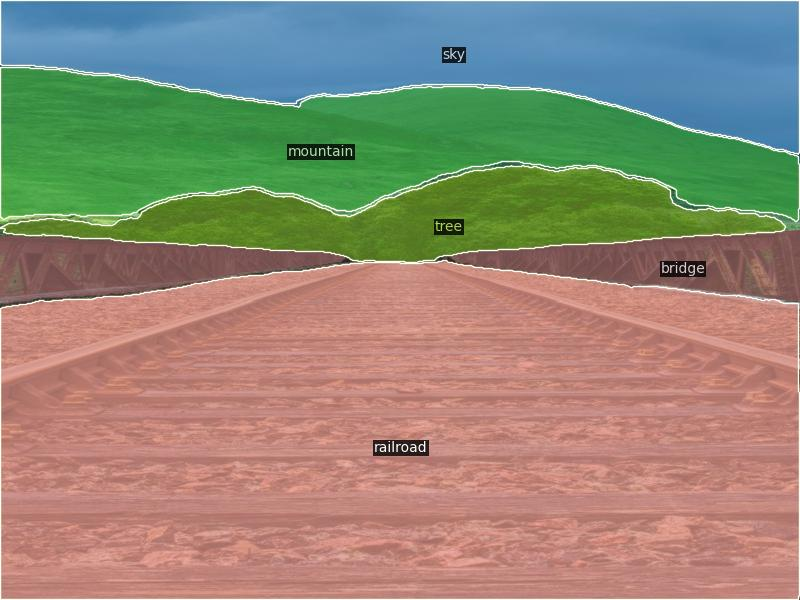

/content/output/다람쥐.jpg


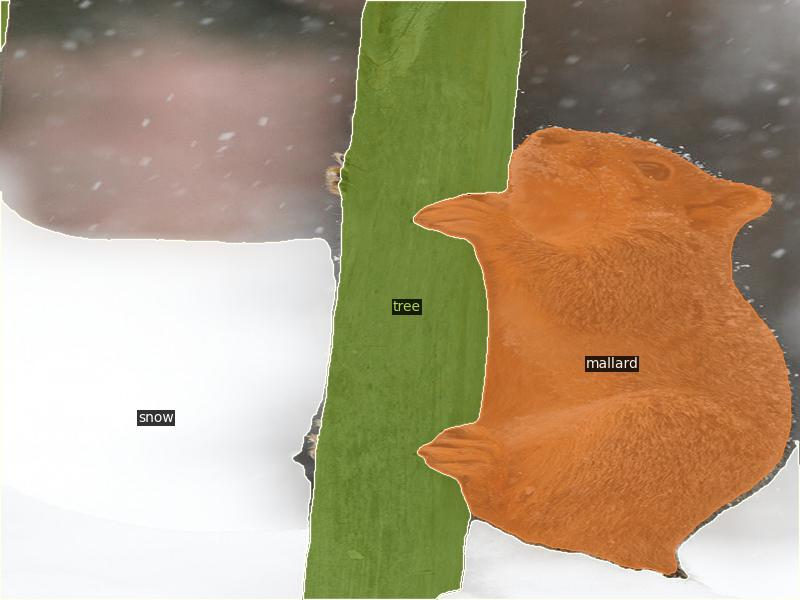

/content/output/불가사리.jpg


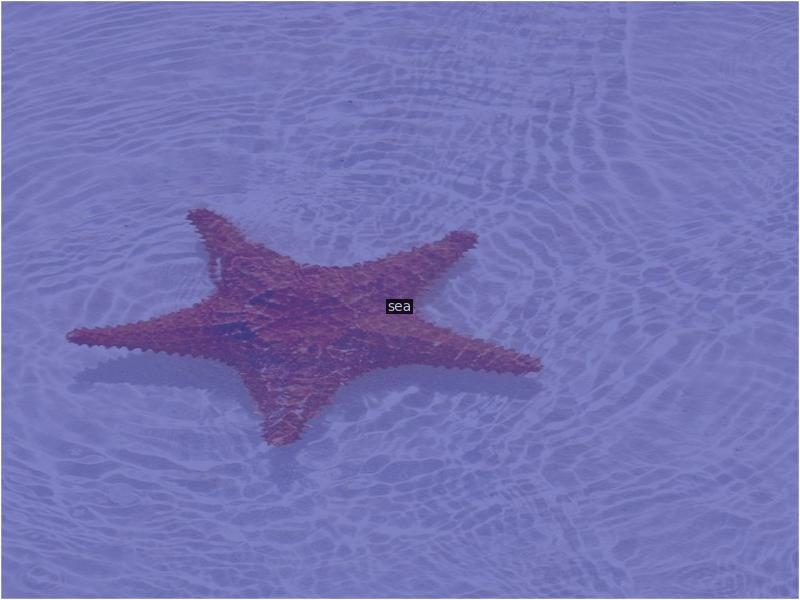

In [ ]:
from IPython.display import Image, display
import glob

for img_path in sorted(glob.glob('/content/output/*.jpg')):
    print(img_path)
    display(Image(img_path))

In [ ]:
from PIL import Image
import os

input_dir = '/content/drive/MyDrive/FC-CLIP'
output_dir = '/content/resized'
os.makedirs(output_dir, exist_ok=True)

names = ['기찻길', '다람쥐', '불가사리']
for name in names:
    img = Image.open(f'{input_dir}/{name}.jpg')
    print(f'{name} 원본: {img.size}')
    img_resized = img.resize((800, 600))
    img_resized.save(f'{output_dir}/{name}.jpg')
    print(f'{name} 변환 완료: {img_resized.size}')

기찻길 원본: (1440, 2560)
기찻길 변환 완료: (800, 600)
다람쥐 원본: (640, 960)
다람쥐 변환 완료: (800, 600)
불가사리 원본: (640, 960)
불가사리 변환 완료: (800, 600)


In [ ]:
# 1. Drive 마운트
from google.colab import drive
drive.mount('/content/drive')

# 2. 폴더 이동
%cd /content/drive/MyDrive/FC-CLIP/fc-clip-main

# 3. 바로 실행
!python demo/demo.py \
  --config-file configs/coco/panoptic-segmentation/fcclip/fcclip_convnext_large_eval_ade20k_r50.yaml \
  --input /content/drive/MyDrive/FC-CLIP/기찻길.jpg /content/drive/MyDrive/FC-CLIP/다람쥐.jpg /content/drive/MyDrive/FC-CLIP/볼가사리.jpg \
  --output /content/output/ \
  --opts MODEL.WEIGHTS /content/fc_clip_r50.pth

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/FC-CLIP/fc-clip-main
Traceback (most recent call last):
  File "/content/drive/MyDrive/FC-CLIP/fc-clip-main/demo/demo.py", line 26, in <module>
    from detectron2.config import get_cfg
ModuleNotFoundError: No module named 'detectron2'
